

# Assignment 4: Fine-Tuning do Segment Anything Model (SAM)  

**Introdução:**  
O Segment Anything Model (SAM) é um modelo de segmentação altamente versátil e poderoso, desenvolvido pela Meta AI. Ele foi projetado para lidar com uma ampla gama de tarefas, como segmentar objetos específicos, regiões ou até mesmo identificar múltiplos objetos em uma única imagem sem necessidade de treinamento adicional.  

O SAM utiliza uma abordagem baseada em *prompts*, permitindo que os usuários forneçam diferentes tipos de entrada, como pontos, caixas delimitadoras ou máscaras brutas, para guiar o modelo na segmentação desejada. Ele é composto por:  
- **Encoder de Imagem:** Extrai características visuais robustas.  
- **Encoder de Prompts:** Interpreta entradas do usuário.  
- **Mask Decoder:** Gera máscaras de segmentação com alta precisão.  

Apesar de ser altamente generalista, o SAM pode ser ajustado (fine-tuned) para melhorar seu desempenho em tarefas específicas. Este processo envolve utilizar dados especializados e adaptar o modelo às necessidades de aplicações como segmentação médica, agricultura, monitoramento ambiental, entre outras.  

**Objetivo:**  
Realizar o fine-tuning do SAM para uma tarefa de segmentação específica à sua escolha, demonstrando os passos e resultados por meio de uma apresentação de 10 minutos.  

**Instruções:**  

1. **Escolha da Tarefa:**  
   Selecione uma aplicação prática de segmentação para o fine-tuning do SAM, como:  
   - Segmentação de objetos em ambientes urbanos.  
   - Identificação de características em imagens médicas.  
   - Monitoramento de mudanças em imagens de satélite.  

2. **Preparação do Dataset:**  
   - Utilize ou construa um dataset relevante para sua tarefa.  
   - Divida os dados em treino, validação e teste.  
   - Aplique técnicas de *data augmentation* caso necessário.  

3. **Adaptação do SAM:**  
   - Use o SAM pré-treinado como base.  
   - Adapte sua arquitetura para atender aos requisitos da tarefa.  
   - Decida se congelará partes do modelo ou ajustará todas as camadas.  

4. **Treinamento:**  
   - Configure parâmetros como número de épocas, taxa de aprendizado e tamanho do batch.  
   - Utilize métricas adequadas (como IoU ou Dice Coefficient) para avaliar o desempenho do modelo ajustado.  

5. **Análise e Resultados:**  
   - Compare os resultados do modelo original (pré-treinado) com o modelo ajustado (fine-tuned).  
   - Destaque os desafios enfrentados e as soluções adotadas durante o fine-tuning.  

6. **Entrega:**  
   A entrega será feita por meio de um vídeo gravado de no máximo 10 minutos, contendo:  
   - Breve introdução ao SAM e à tarefa escolhida.  
   - Explicação sobre o dataset e adaptações feitas no modelo.  
   - Resultados e comparações entre o SAM original e o modelo ajustado.  
   - Conclusões e sugestões de melhorias ou aplicações futuras.  

**Dicas:**  
- Use a [documentação oficial do SAM](https://github.com/facebookresearch/segment-anything) como guia técnico.  
- Experimente congelar diferentes partes do modelo e observe como isso afeta o desempenho.  


In [16]:
%pip install git+https://github.com/facebookresearch/segment-anything.git
%pip install opencv-python pycocotools matplotlib onnxruntime onnx
%pip install opendatasets

!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-dbcrmoz6
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-dbcrmoz6
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
--2025-11-21 18:33:42--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.238.192.122, 18.238.192.60, 18.238.192.99, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.238.192.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth.1’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   203MB/s    in 1.8s    

2025-11-21 18:33:44 (203 MB/s) - ‘sam_vit_b_01ec64.pth.1’ saved [375042383/375042383]



In [17]:
import torch
import kagglehub
from segment_anything import SamPredictor, sam_model_registry
import numpy as np

from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import v2
import torchvision.transforms as transforms
from torchvision.io import decode_image
from torch.utils.data import random_split

from matplotlib import pyplot as plt

from tqdm import tqdm

from os.path import join
from glob import glob
import json

DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
DEVICE

'cuda'

# Dataset

In [18]:
TOOTH_DATASET_PATH = kagglehub.dataset_download("vitordonascimento/dental-dataset")
#TOOTH_DATASET_PATH = "/kaggle/input/dental-dataset"
TOOTH_DATASET_PATH

Using Colab cache for faster access to the 'dental-dataset' dataset.


'/kaggle/input/dental-dataset'

Extraindo média e desvio padrão da base de dados

In [19]:
def get_sample_mean_and_std_ds(dataset_path, image_type="jpg", device=DEVICE):
    data = glob(join(dataset_path, "*." + image_type))

    N = len(data)

    means_sum = torch.zeros(3)
    stds_sum = torch.zeros(3)
    
    for i in range(N):
        image = decode_image(data[i]).to(torch.float).to(device)
        means_sum += torch.tensor([image[0].mean(), image[1].mean(), image[2].mean()]).to(torch.float)
        stds_sum += torch.tensor([image[0].std(), image[1].std(), image[2].std()]).to(torch.float)

    return means_sum / N, stds_sum / N

DS_MEAN, DS_STD = get_sample_mean_and_std_ds(join(TOOTH_DATASET_PATH, "dental-dataset", "adult", "images"))
DS_MEAN, DS_STD

(tensor([95.6162, 95.6162, 95.6162]), tensor([41.6408, 41.6408, 41.6408]))

Classe para carregar o dataset

In [40]:
class SegmentationDataset(Dataset):
    def __init__(self, dataset="adult", image_size=None, normalize=True, dataset_path=TOOTH_DATASET_PATH, device=DEVICE):
            
        self._path_data = join(dataset_path, "dental-dataset", dataset, "images")
        self._path_masks = join(dataset_path, "dental-dataset", dataset, "masks")

        self.data = glob(join(self._path_data, "*.jpg"))

        self.device = device

        if image_size:
            self.resize_image = v2.Resize(size=image_size, interpolation=v2.InterpolationMode.BILINEAR, antialias=True)
            self.resize_mask = v2.Resize(size=image_size, interpolation=v2.InterpolationMode.NEAREST)
        else:
            self.resize_image = lambda x: x
            self.resize_mask = lambda x: x

        self.normalize_image = v2.Compose([v2.Normalize(DS_MEAN, DS_STD), 
                                           lambda x : torch.clamp(x, 0.0, 1.0)]) if normalize else lambda x: x
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        image_path = self.data[index]
        name = image_path.split("/")[-1].split(".")[0]
        mask_path = join(self._path_masks, f"{name[:-3]}mask.png")

        image = decode_image(image_path).to(torch.float).to(self.device)
        mask = decode_image(mask_path)

        image = self.resize_image(image)
        image = self.normalize_image(image)
        mask = self.resize_mask(mask)

        return image, mask

    def orig_image(self, index):
        image_path = self.data[index]
        return decode_image(image_path)

Função para fazer split do dataset

In [43]:
def get_train_test_split(dataset, test_prop=0.2):
    n_features = len(dataset)
    
    test_size = round(n_features * test_prop)
    train_size = n_features - test_size

    return random_split(dataset, [train_size, test_size])

1328 443 443
torch.Size([3, 256, 512])
torch.Size([3, 256, 512])


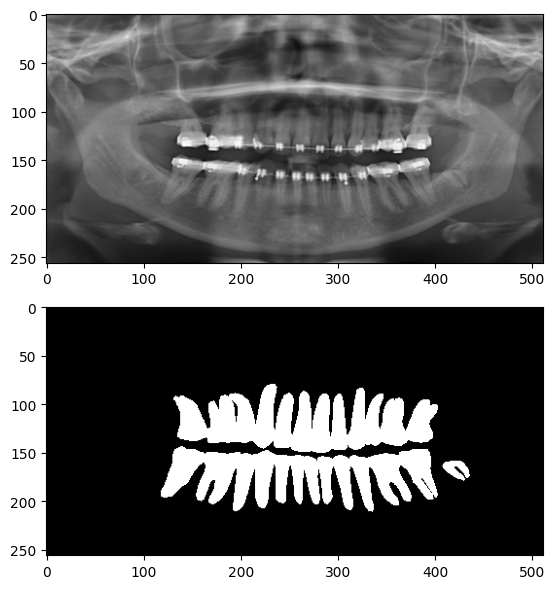

In [45]:
# Exemplo de uso do dataset com split
data = SegmentationDataset(image_size=[256, 512], normalize=False, device="cpu")

ds_train, ds_test = get_train_test_split(data)
ds_train, ds_val = get_train_test_split(ds_train, 1/4)

print(len(ds_train), len(ds_val), len(ds_test))

for i in range(2):
    imgs_train, masks_train = ds_train[i]
    print(imgs_train.shape)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
axes[0].imshow(imgs_train.permute(1, 2, 0).to(torch.uint8).to("cpu"))
axes[1].imshow(masks_train.permute(1, 2, 0).to(torch.uint8).to("cpu"))
plt.tight_layout()

# Modelo SAM

In [46]:
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"

In [47]:
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(DEVICE)

for name, param in sam.named_parameters():
    if name.startswith("image_encoder") or name.startswith("prompt_encoder"):
        param.requires_grad = False
    else:
        param.requires_grad = True

In [48]:
def plot_model_preds(model_output, test_image, test_label):
    if torch.max(test_image) <= 1.0:
        test_image *= 255.0
    masks, confidences, _ = model_output
    number_masks = masks.shape[0] + 1

    fig, axes = plt.subplots(number_masks, 1, figsize = (6, number_masks * 3))
    axes[0].set_title("Ground Truth")
    axes[0].imshow(test_image.permute(1, 2, 0).to(torch.uint8))
    axes[0].imshow(test_label.permute(1, 2, 0).to(torch.uint8), cmap = "spring", alpha = 0.5)

    for i in range(1, number_masks):
        axes[i].imshow(test_image.permute(1, 2, 0).to(torch.uint8))
        masked_overlay = np.ma.masked_where(masks[i - 1] == 0, masks[i - 1])
        axes[i].imshow(masked_overlay, cmap = "spring", alpha = 0.5)
        axes[i].set_title(f"pred {i - 1} | Confidence: {confidences[i - 1]}")
        plt.tight_layout()

torch.Size([256, 512, 3])


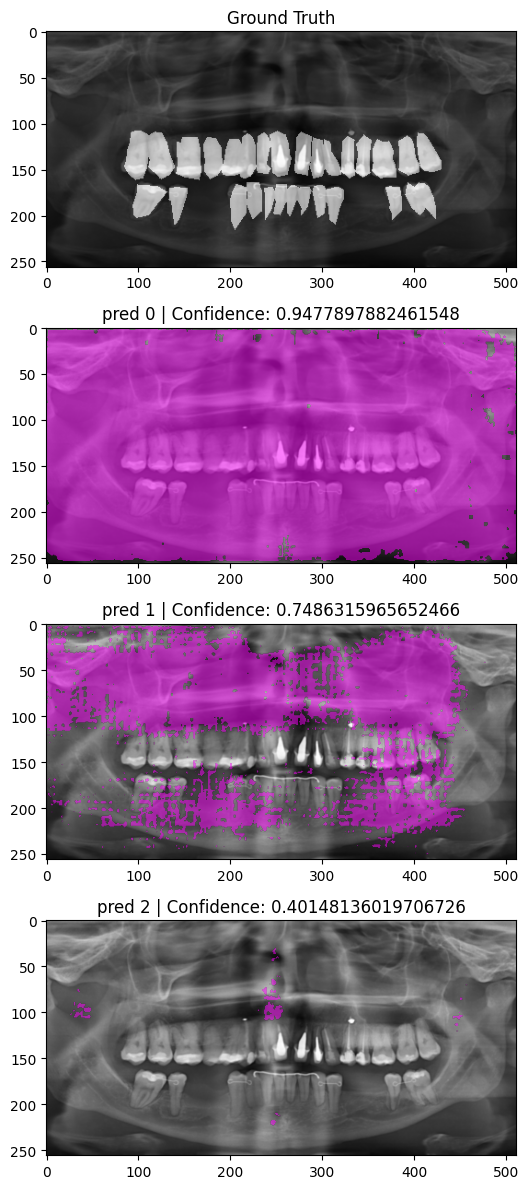

In [49]:
#Imagens usadas para testar output do modelo
test_image, test_label = ds_train[0]

#Cria um predictor e define a imagem pra fazer ot este
predictor = SamPredictor(sam)
print(test_image.permute(1, 2, 0).shape)
predictor.set_image(test_image.permute(1, 2, 0).numpy())

#Faz um teste usando um prompt de ponto
pontos = np.array(
    ((250, 100),
     (250, 20),
     (250, 230),
     (20, 100),
     (460, 100))
)
labels = np.array((1, 0, 0, 0, 0))
output = predictor.predict(point_coords = pontos, point_labels = labels)

plot_model_preds(output, test_image, test_label)

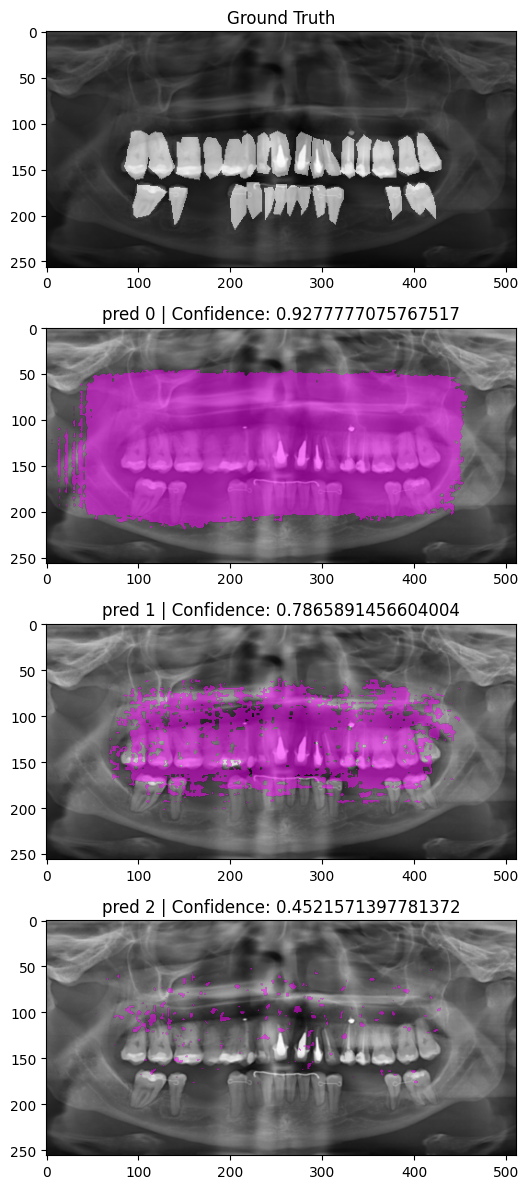

In [50]:
#Faz um teste usando um prompt de caixa
caixa = np.array((50, 50, 450, 200))
output = predictor.predict(box = caixa)

plot_model_preds(output, test_image, test_label)

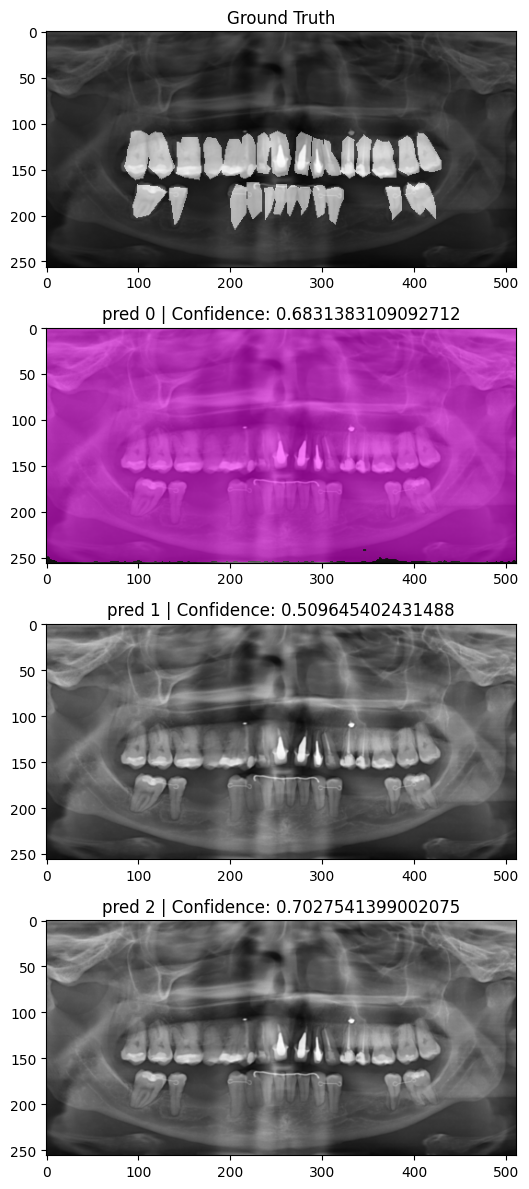

In [51]:
#Faz um teste sem usar prompt
output = predictor.predict()

plot_model_preds(output, test_image, test_label)

# Treino

In [52]:

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, sam.parameters()), 
    lr=1e-4,
    weight_decay=0
)

loss_fn = torch.nn.MSELoss()

In [53]:
class Trainer():
    def __init__(self, criterion, device):
        self.criterion = criterion
        self._device = device

        self.history = {
            "epochs": 0,
            "train_loss": [],
            "val_loss": []
        }

    def _prepare_batch_input(self, images, bboxes, original_sizes):
        batched_input = []
        for i in range(len(images)):
            dict_input = {
                "image": images[i], 
                "boxes": bboxes[i].unsqueeze(0),
                "original_size": original_sizes[i]
            }
            batched_input.append(dict_input)
        return batched_input

    def train_one_epoch(self, optimizer, train_loader, epoch):
        self.train()
        running_loss = 0.0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1} | Training")
        for i, batch in enumerate(progress_bar):
            images = batch["image"].to(self._device)          
            bboxes = batch["boxes"].to(self._device)          
            gt_masks = batch["masks"].to(self._device)        
            original_sizes = batch["original_size"]     

            batched_input = self._prepare_batch_input(images, bboxes, original_sizes)

            self.optimizer.zero_grad()

            outputs = self.model(batched_input, multimask_output=False)

            loss = 0
            for output, gt_mask in zip(outputs, gt_masks):
                # TODO
                ...
            
            loss = loss / len(outputs)
            
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix(loss=running_loss / (i + 1))

        epoch_loss = running_loss / len(train_loader)
        return epoch_loss

    def validate_one_epoch(self, optimizer, val_loader, epoch):
        ...

    def save_model(self, path = None):
        if path:
            json_path = join(*path, f"{self.__class__.__name__}.json")    
            pth_path = join(*path, f"{self.__class__.__name__}.pth")
        else:
            json_path = f"{self.__class__.__name__}.json"
            pth_path = f"{self.__class__.__name__}.pth"
        with open(json_path, "w", encoding = "utf-8") as f:
            json.dump(self.history, f, ensure_ascii = False, indent = 4)
        torch.save(self.state_dict(), pth_path)
    
    def load_model(self, path = None, name = None):
        name = name if name else self.__class__.__name__
        if path:
            json_path = join(*path, f"{name}.json")    
            pth_path = join(*path, f"{name}.pth")
        else:
            json_path = f"{name}.json"
            pth_path = f"{name}.pth"
        with open(json_path, "r", encoding = "utf-8") as f:
            self.history = json.load(f)
        self.load_state_dict(torch.load(pth_path, map_location=torch.device(DEVICE), weights_only = True))

    def fit(self, train_loader, val_loader, optimizer, num_epochs, scheduler = None):
        for epoch in range(self.history["epochs"], self.history["epochs"] + num_epochs):
            train_loss = self.train_one_epoch(optimizer, train_loader, epoch)
            val_loss = self.validate_one_epoch(optimizer, val_loader, epoch)

            print(f"Fim Epoch {epoch+1}:")
            print(f"   -> Loss train: {train_loss:.3f} | Loss val: {val_loss:.3f}")
            if scheduler:
                scheduler.step(val_loss)
                print(f"   -> LR: {scheduler.get_last_lr()[0]:.6f}\n")

            self.history["epochs"] = epoch
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)

            if epoch % 5 == 0:
                self.save_model()

        return self.history